# Census Data Collector `censusdc` basic example

This example shows the basic usage of the census data collector using all supported queryable products:

* Tigerweb
* Summary File 3 of the Decennial Census (SF3)
* Acs 1-Year
* Acs 5-Year

Start by importing some necessary packages for this example

In [23]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

and import classes from the census data collector

In [2]:
from censusdc import TigerWeb, Acs1, Acs5, Sf3

### Note: a census API key is necessary for this example. Please redefine the `apikey` variable to reflect your personal census API key

A personal API key can be obtained from https://api.census.gov/data/key_signup.html

In [3]:
apikey = Path("../api_key.dat")
with open(apikey) as api:
    apikey = api.readline().strip()

## Grab census designated place information from TigerWeb

TigerWeb provides census geographies and geocodes that can be used to spatialally query data from census products. TigerWeb data calls return geoJSON features. We'll be grabbing tigerweb infromation for a couple Sacramento, CA neighborhoods using this shapefile

<p align="center">
  <img src="https://raw.githubusercontent.com/jlarsen-usgs/census-data-collector/master/data/Sacramento_neighborhoods.png" alt="Sacto"/>
</p>

In [4]:
shp_file = Path('../data/Sacramento_neighborhoods.shp')
gdf = gpd.read_file(shp_file)
gdf.head()

,Id,name,geometry
0,0,La_riviera,"POLYGON ((122918.078 4278978.134, 123057.108 4..."
1,0,Tahoe_park,"POLYGON ((111068.007 4277472.914, 111256.009 4..."


The shapefile can have multiple polygons defined and will be treated as multiple features. If there is a specific association for the polygon within the shapefile we can tag it using one of the `TigerWeb` class parameters. The `TigerWeb` class parameters include:

* `gdf`: geopandas GeoDataFrame
* `field`: shapefile attribute to identify multiple polygons

In [5]:
tigweb = TigerWeb(gdf, field='name')

__Querying data using the `TigerWeb` class__

Once we instantiate the `TigerWeb` class it can be used to query data from the census TigerWeb REST servers using the `get_data()` method. The `get_data()` method has a number of optional parameters that can be passed to it, however it is recommended that the user uses the defaults unless they have a good understanding of the census data product they are requesting. `get_data()` parameters are:

* `year`: Year of data request (1990, 2000, and 2004 - 2024 are supported)
* `level`: default "finest", census designated place level ("tract" and/or "county" are recommended options)
* `outfields`: TigerWeb rest server variables. Default `()` grabs most TigerWeb variables

Let's grab tract level data for the 2000 Decenial census

In [6]:
tigweb.get_data(2000, level='tract')

Received 13 entries, 13 total, from server 8
Received 6 entries, 6 total, from server 8


We can examine this data by grabbing a copy of the features using the `get_feature()` method. This returns a list of geoJSON features.

In [7]:
# get the feature names
names = tigweb.feature_names
print(names)

la_riv = tigweb.get_feature(names[0])
la_riv

['La_riviera', 'Tahoe_park']


,geometry,GEOID,STATE,COUNTY,TRACT,AREAWATER,name
0,"POLYGON ((116650.003 4277424.314, 116443.385 4...",06067005202,06,067,005202,113923,La_riviera
1,"POLYGON ((120975.148 4278730.642, 120878.463 4...",06067005804,06,067,005804,368436,La_riviera
2,"POLYGON ((118484.777 4273176.598, 118689.226 4...",06067005203,06,067,005203,0,La_riviera
3,"POLYGON ((119197.121 4275581.295, 119292.682 4...",06067009109,06,067,009109,0,La_riviera
4,"POLYGON ((121173.805 4278832.06, 121344.525 42...",06067005803,06,067,005803,0,La_riviera
5,"POLYGON ((123808.733 4278389.86, 123808.112 42...",06067009006,06,067,009006,0,La_riviera
6,"POLYGON ((114837.276 4277486.301, 114832.988 4...",06067005201,06,067,005201,168225,La_riviera
7,"POLYGON ((117346.391 4278671.9, 117312.967 427...",06067005404,06,067,005404,164181,La_riviera
8,"POLYGON ((120990.696 4278702.974, 120181.252 4...",06067009107,06,067,009107,367880,La_riviera
9,"POLYGON ((118771.957 4276961.927, 118693.692 4...",06067009110,06,067,009110,0,La_riviera


We can also define which variable we would like to get in a data pull by using supplying tigerweb variable names to the `outfields` parameter of the `get_data()` method.

Let's rerun the data pull using variables from `TigerWebVariables` class

In [8]:
from censusdc import TigerWebVariables

outfields = (TigerWebVariables.state, TigerWebVariables.county, TigerWebVariables.tract)
tigweb.get_data(2000, level='tract', outfields=outfields)

names = tigweb.feature_names
la_riv = tigweb.get_feature(names[0])
la_riv

Received 13 entries, 13 total, from server 8
Received 6 entries, 6 total, from server 8


,geometry,STATE,COUNTY,TRACT,GEOID,name
0,"POLYGON ((116650.003 4277424.314, 116443.385 4...",06,067,005202,06067005202,La_riviera
1,"POLYGON ((120975.148 4278730.642, 120878.463 4...",06,067,005804,06067005804,La_riviera
2,"POLYGON ((118484.777 4273176.598, 118689.226 4...",06,067,005203,06067005203,La_riviera
3,"POLYGON ((119197.121 4275581.295, 119292.682 4...",06,067,009109,06067009109,La_riviera
4,"POLYGON ((121173.805 4278832.06, 121344.525 42...",06,067,005803,06067005803,La_riviera
5,"POLYGON ((123808.733 4278389.86, 123808.112 42...",06,067,009006,06067009006,La_riviera
6,"POLYGON ((114837.276 4277486.301, 114832.988 4...",06,067,005201,06067005201,La_riviera
7,"POLYGON ((117346.391 4278671.9, 117312.967 427...",06,067,005404,06067005404,La_riviera
8,"POLYGON ((120990.696 4278702.974, 120181.252 4...",06,067,009107,06067009107,La_riviera
9,"POLYGON ((118771.957 4276961.927, 118693.692 4...",06,067,009110,06067009110,La_riviera


## Getting data from the Decennial census

The `Sf3` class supports user user queries to the decennial summary file 3 census product for `1990` and `2000`. The `Sf3` is not available for 2010 and it is recommended that the user looks at the American community survey 5 year product for 2010.

Parameters for the `Sf3` include:
   * `features`: dictionary of features from the tigerweb data pull
   * `year`: year of census data request (1990 and 2000 are supported)
   * `apikey`: user's specific census api key string

In [9]:
sf3 = Sf3(tigweb.features, 2000, apikey)

__pulling data using the `get_data()` method__:

The `get_data()` method is defined with a number of default parameters to work with the `TigerWeb` class. Of note, it can automatically determine the finest resolution of data it can pull from the product information and the features supplied to it. The user can also specify this. Parameters for the `get_data()` method include:
   * `level`: default is finest, or the user can set it to their TigerWeb resolution
   * `variables`: default pulls population and economic variables for the census designated place. The user can alternatively supply a tuple of census variable codes.
   * `retry`: default 100. Retry facilitates a number of data request retries for intermittent internet outages and/or slow connections.
    

In [10]:
sf3.get_data(level='tract')

Getting tract data for GEOID 06067005202
Getting tract data for GEOID 06067005804
Getting tract data for GEOID 06067005203
Getting tract data for GEOID 06067009109
Getting tract data for GEOID 06067005803
Getting tract data for GEOID 06067009006
Getting tract data for GEOID 06067005201
Getting tract data for GEOID 06067005404
Getting tract data for GEOID 06067009107
Getting tract data for GEOID 06067009110
Getting tract data for GEOID 06067008909
Getting tract data for GEOID 06067009106
Getting tract data for GEOID 06067009105
Getting tract data for GEOID 06067002900
Error getting tract data for GEOID 06067002900
Getting tract data for GEOID 06067004401
Getting tract data for GEOID 06067003000
Error getting tract data for GEOID 06067003000
Getting tract data for GEOID 06067001700
Error getting tract data for GEOID 06067001700
Getting tract data for GEOID 06067002800
Error getting tract data for GEOID 06067002800
Getting tract data for GEOID 06067001800
Error getting tract data for GEOI

Data is stored as a geopandas dataframe in the Sf3 class.

In [11]:
features = sf3.features
features.head()

,geometry,STATE,COUNTY,TRACT,GEOID,name,P001001,P052001,P052002,P052003,...,P052010,P052011,P052012,P052013,P052014,P052015,P052016,P052017,HCT012001,H035001
0,"POLYGON ((116650.003 4277424.314, 116443.385 4...",06,067,005202,06067005202,La_riviera,3206.0,1463.0,153.0,52.0,...,89.0,125.0,205.0,133.0,70.0,27.0,32.0,8.0,44074.0,1973.0
1,"POLYGON ((120975.148 4278730.642, 120878.463 4...",06,067,005804,06067005804,La_riviera,2659.0,1115.0,84.0,49.0,...,51.0,68.0,73.0,170.0,98.0,78.0,112.0,156.0,80295.0,1972.0
2,"POLYGON ((118484.777 4273176.598, 118689.226 4...",06,067,005203,06067005203,La_riviera,7140.0,3220.0,295.0,164.0,...,152.0,265.0,409.0,279.0,202.0,106.0,65.0,10.0,41712.0,1969.0
3,"POLYGON ((119197.121 4275581.295, 119292.682 4...",06,067,009109,06067009109,La_riviera,5096.0,1761.0,44.0,19.0,...,117.0,211.0,278.0,308.0,167.0,60.0,67.0,4.0,60264.0,1974.0
4,"POLYGON ((121173.805 4278832.06, 121344.525 42...",06,067,005803,06067005803,La_riviera,3491.0,1428.0,60.0,15.0,...,70.0,114.0,129.0,174.0,158.0,139.0,114.0,182.0,81325.0,1966.0


The user can also define their own variables to grab by supplying census variable names or by using the `Sf3Variables` or `Sf3Variables1990` objects.

Let's redo the data pull and only grab population and households.

Our first step is to load up the default variables for the Decennial Census from `Sf3Defaults`

In [12]:
from censusdc.datacollector.dec import Sf3Defaults

defaults = Sf3Defaults()
dfd = defaults.dataframe
dfd.head()

,name,cen_code
0,population,P001001
1,households,P052001
2,income_lt_10k,P052002
3,income_10K_15k,P052003
4,income_15k_20k,P052004


In [13]:
# filter the dataframe for only pop. and hous.
dfd = dfd[dfd.name.isin(["population", "households"])]

sf3.get_data(level='finest', variables=dfd.cen_code.tolist())

sf3.features.head()

Getting tract data for GEOID 06067005202
Getting tract data for GEOID 06067005804
Getting tract data for GEOID 06067005203
Getting tract data for GEOID 06067009109
Getting tract data for GEOID 06067005803
Getting tract data for GEOID 06067009006
Getting tract data for GEOID 06067005201
Getting tract data for GEOID 06067005404
Getting tract data for GEOID 06067009107
Getting tract data for GEOID 06067009110
Getting tract data for GEOID 06067008909
Getting tract data for GEOID 06067009106
Getting tract data for GEOID 06067009105
Getting tract data for GEOID 06067002900
Error getting tract data for GEOID 06067002900
Getting tract data for GEOID 06067004401
Getting tract data for GEOID 06067003000
Error getting tract data for GEOID 06067003000
Getting tract data for GEOID 06067001700
Error getting tract data for GEOID 06067001700
Getting tract data for GEOID 06067002800
Error getting tract data for GEOID 06067002800
Getting tract data for GEOID 06067001800
Error getting tract data for GEOI

,geometry,STATE,COUNTY,TRACT,GEOID,name,P001001,P052001
0,"POLYGON ((116650.003 4277424.314, 116443.385 4...",06,067,005202,06067005202,La_riviera,3206.0,1463.0
1,"POLYGON ((120975.148 4278730.642, 120878.463 4...",06,067,005804,06067005804,La_riviera,2659.0,1115.0
2,"POLYGON ((118484.777 4273176.598, 118689.226 4...",06,067,005203,06067005203,La_riviera,7140.0,3220.0
3,"POLYGON ((119197.121 4275581.295, 119292.682 4...",06,067,009109,06067009109,La_riviera,5096.0,1761.0
4,"POLYGON ((121173.805 4278832.06, 121344.525 42...",06,067,005803,06067005803,La_riviera,3491.0,1428.0


And we can rename the dataframe columns to something human readable

In [14]:
dfcen = sf3.features
renames = {r["cen_code"]: r["name"] for _, r in dfd.iterrows()}
dfcen = dfcen.rename(columns=renames)
dfcen.head()

,geometry,STATE,COUNTY,TRACT,GEOID,name,population,households
0,"POLYGON ((116650.003 4277424.314, 116443.385 4...",06,067,005202,06067005202,La_riviera,3206.0,1463.0
1,"POLYGON ((120975.148 4278730.642, 120878.463 4...",06,067,005804,06067005804,La_riviera,2659.0,1115.0
2,"POLYGON ((118484.777 4273176.598, 118689.226 4...",06,067,005203,06067005203,La_riviera,7140.0,3220.0
3,"POLYGON ((119197.121 4275581.295, 119292.682 4...",06,067,009109,06067009109,La_riviera,5096.0,1761.0
4,"POLYGON ((121173.805 4278832.06, 121344.525 42...",06,067,005803,06067005803,La_riviera,3491.0,1428.0


## Grabbing data from the American Community Survey Products

The syntax for grabbing data from the American Community Survey Products is the same as grabbing data from the Summary File 3 which was shown in the prior example. Some notes and gotchas are as follows:

__Note__:
   * ACS1 data is available for 2005 through 2018
   * ACS5 data is available for 2009 through 2018

__Gotcha's__:
   * Although the finest resolution for ACS1 is `level=county_subdivision`, it is highly reccomended to specify `level=county` for ACS1 data. The census api has been unreliable for returning county_subdivision data from the ACS1 products.

In [15]:
# An ACS1 example
from censusdc.datacollector.acs import Acs5Defaults
year = 2005
level = "county"

tigweb = TigerWeb(gdf, field='name')
tigweb.get_data(year, level=level)

defaults = Acs5Defaults()
dfd = defaults.dataframe
dfd = dfd[dfd.name.isin(["population", "median_income"])]

variables = dfd.cen_code.tolist()
acs1 = Acs1(tigweb.features, year, apikey)
acs1.get_data(level=level, variables=variables)

feats = acs1.features
feats.head()


Received 1 entries, 1 total, from server 1
Received 1 entries, 1 total, from server 1
Getting county data for GEOID 06067
Getting county data for GEOID 06067


,geometry,GEOID,STATE,COUNTY,AREALAND,AREAWATER,name,B01003_001E,B19013_001E
0,"POLYGON ((111452.756 4243499.119, 111472.855 4...",06067,06,067,2500322890,75063499,La_riviera,1337942.0,51793.0
1,"POLYGON ((111452.756 4243499.119, 111472.855 4...",06067,06,067,2500322890,75063499,La_riviera,1337942.0,51793.0
2,"POLYGON ((111452.756 4243499.119, 111472.855 4...",06067,06,067,2500322890,75063499,Tahoe_park,1337942.0,51793.0
3,"POLYGON ((111452.756 4243499.119, 111472.855 4...",06067,06,067,2500322890,75063499,Tahoe_park,1337942.0,51793.0


In [16]:
# An ACS5 example
year = 2010
level = "tract"

tigweb = TigerWeb(gdf, field="name")
tigweb.get_data(year, level=level)

defaults = Acs5Defaults()
dfd = defaults.dataframe
dfd = dfd[dfd.name.isin(["population", "median_income"])]

variables = dfd.cen_code.tolist()
acs5 = Acs5(tigweb.features, year, apikey)
acs5.get_data(level=level, variables=variables)

features = acs5.features
features

Received 14 entries, 14 total, from server 10
Received 6 entries, 6 total, from server 10
Getting tract data for GEOID 06067005204
Getting tract data for GEOID 06067005205
Getting tract data for GEOID 06067009006
Getting tract data for GEOID 06067009109
Getting tract data for GEOID 06067009107
Getting tract data for GEOID 06067009106
Getting tract data for GEOID 06067005803
Getting tract data for GEOID 06067005804
Getting tract data for GEOID 06067009110
Getting tract data for GEOID 06067008909
Getting tract data for GEOID 06067005201
Getting tract data for GEOID 06067005202
Getting tract data for GEOID 06067009105
Getting tract data for GEOID 06067005404
Getting tract data for GEOID 06067001800
Getting tract data for GEOID 06067004401
Getting tract data for GEOID 06067002800
Getting tract data for GEOID 06067002900
Getting tract data for GEOID 06067003000
Getting tract data for GEOID 06067001700


,geometry,GEOID,STATE,COUNTY,TRACT,AREAWATER,name,B01003_001E,B19013_001E
0,"POLYGON ((116235.265 4276427.896, 116234.763 4...",06067005204,06,067,005204,0,La_riviera,4289.0,54226.0
1,"POLYGON ((114628.018 4276232.19, 114639.915 42...",06067005205,06,067,005205,0,La_riviera,2203.0,32612.0
2,"POLYGON ((122166.963 4278259.556, 122167.624 4...",06067009006,06,067,009006,0,La_riviera,4775.0,37333.0
3,"POLYGON ((118695.346 4276267.918, 118709.427 4...",06067009109,06,067,009109,0,La_riviera,4835.0,76328.0
4,"POLYGON ((120226.311 4278193.969, 120247.751 4...",06067009107,06,067,009107,167427,La_riviera,3238.0,65861.0
5,"POLYGON ((118094.389 4277817.694, 118094.78 42...",06067009106,06,067,009106,172671,La_riviera,3985.0,54213.0
6,"POLYGON ((119320.402 4279099.659, 119377.126 4...",06067005803,06,067,005803,351882,La_riviera,3365.0,105189.0
7,"POLYGON ((120892.764 4280116.484, 120878.692 4...",06067005804,06,067,005804,325415,La_riviera,2542.0,91667.0
8,"POLYGON ((118346.851 4276925.453, 118358.768 4...",06067009110,06,067,009110,0,La_riviera,1353.0,32639.0
9,"POLYGON ((122169.712 4278343.556, 122169.434 4...",06067008909,06,067,008909,205020,La_riviera,2287.0,81667.0


## Performing area weighted intersections on census features:

The `GeoFeatures` class can be used to perform area weighted intersections on the census features and census data.

Let's do a complete example of pulling census data and then intersecting it with one of our defining features from our input shape file.


In [17]:
from censusdc.utils import area_weighted_resampling

year = 2010
level = "tract"

tigweb = TigerWeb(gdf, field='name')
tigweb.get_data(year, level=level)

defaults = Acs5Defaults()
dfd = defaults.dataframe
dfd = dfd[dfd.name.isin(["population", "median_income"])]

variables = dfd.cen_code.tolist()
acs5 = Acs5(tigweb.features, year, apikey)
acs5.get_data(level=level, variables=variables)


Received 14 entries, 14 total, from server 10
Received 6 entries, 6 total, from server 10
Getting tract data for GEOID 06067005204
Getting tract data for GEOID 06067005205
Getting tract data for GEOID 06067009006
Getting tract data for GEOID 06067009109
Getting tract data for GEOID 06067009107
Getting tract data for GEOID 06067009106
Getting tract data for GEOID 06067005803
Getting tract data for GEOID 06067005804
Getting tract data for GEOID 06067009110
Getting tract data for GEOID 06067008909
Getting tract data for GEOID 06067005201
Getting tract data for GEOID 06067005202
Getting tract data for GEOID 06067009105
Getting tract data for GEOID 06067005404
Getting tract data for GEOID 06067001800
Getting tract data for GEOID 06067004401
Getting tract data for GEOID 06067002800
Getting tract data for GEOID 06067002900
Getting tract data for GEOID 06067003000
Getting tract data for GEOID 06067001700


### The `area_weighted_resampling` funtion

The area weighted resampling function has a number of different methods that can be applied within an area weighted context and different ones may need to be applied to different data types. For example, "accumulate" or "sum" may be the best way to resample to a new geometry for census data like population. 'mean' or 'median' may be more appropriate for data such as "median income".

Let's look at a couple examples here

In [18]:
features = acs5.features
renames = {r["cen_code"]: r["name"] for _, r in dfd.iterrows()}
features = features.rename(columns=renames)
features.head()

,geometry,GEOID,STATE,COUNTY,TRACT,AREAWATER,name,population,median_income
0,"POLYGON ((116235.265 4276427.896, 116234.763 4...",06067005204,06,067,005204,0,La_riviera,4289.0,54226.0
1,"POLYGON ((114628.018 4276232.19, 114639.915 42...",06067005205,06,067,005205,0,La_riviera,2203.0,32612.0
2,"POLYGON ((122166.963 4278259.556, 122167.624 4...",06067009006,06,067,009006,0,La_riviera,4775.0,37333.0
3,"POLYGON ((118695.346 4276267.918, 118709.427 4...",06067009109,06,067,009109,0,La_riviera,4835.0,76328.0
4,"POLYGON ((120226.311 4278193.969, 120247.751 4...",06067009107,06,067,009107,167427,La_riviera,3238.0,65861.0


Now to use the `area_weighted_resampling` function to resample `"population"` to our original (shapefile) discretization/geometry:

In [19]:
pop_features = features[["geometry", "GEOID", "population"]]
dfresmaple = area_weighted_resampling(pop_features, gdf, groupby="name", method="accumulate")
dfresmaple

,name,population,Id
0,La_riviera,15892.936816,0.0
1,Tahoe_park,7000.006245,0.0


And for the `"median_income"` we'll use an area weighted `mean` to resample to our original geometries:

In [22]:
med_features = features[["geometry", "GEOID", "median_income"]]
dfresample2 = area_weighted_resampling(med_features, gdf, groupby="name", method="mean")
dfresample2

,name,median_income,Id
0,La_riviera,62093.294907,0.0
1,Tahoe_park,68679.900867,0.0


Finally these dataframes can be joined back together or joined with the original geometries and exported as a shapefile

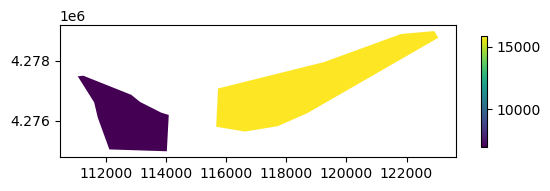

In [31]:
gdfout = pd.merge(gdf, dfresmaple, on="name")
gdfout = pd.merge(gdfout, dfresample2, on="name")
ax = gdfout.plot(column="population", cmap="viridis")
plt.colorbar(ax.collections[0], shrink=0.3);

Optionally we can use the `hr_dict` flag and supply a dictionary of human readable tags to the `GeoFeatures.features_to_dataframe` method. 

For variables in `AcsVariables`, `Sf3Variables`, and `Sf3Variables1990` there are associated built in human readable associations in the:

* `AcsHR`
* `Sf3HR`
* `Sf3HR1990`

## The next notebook: Notebook 2, shows how to use the `CensusTimeSeries` class which combines all of these methods on the backend to return a human readable time series of all available census data for the selected variables!